### Assigment 2

#### 4.1 Topological Ordering of Animal Species

In [2]:
# Cell 0 — Imports & path setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data_lab2")  # <- your folder
rng = np.random.default_rng(0)     # reproducibility


In [7]:
# Cell 1 — Generic SOM helpers (BMU + neighborhoods + training)

def bmu_index(x: np.ndarray, W: np.ndarray) -> int:
    """
    x: (dim,)
    W: (n_nodes, dim)
    Returns BMU index (argmin squared Euclidean distance).
    """
    d2 = np.sum((W - x) ** 2, axis=1)
    return int(np.argmin(d2))


def neighbors_1d(i_star: int, radius: int, n_nodes: int, circular: bool) -> np.ndarray:
    """
    Returns indices within radius in a 1D chain or ring.
    Distance measured in index space. If circular=True, wrap-around is used.
    """
    if radius <= 0:
        return np.array([i_star], dtype=int)

    idx = np.arange(n_nodes, dtype=int)
    if circular:
        # circular distance on ring
        dist = np.minimum((idx - i_star) % n_nodes, (i_star - idx) % n_nodes)
        return idx[dist <= radius]
    else:
        # linear distance on chain
        return idx[np.abs(idx - i_star) <= radius]


def neighbors_2d(bmu_rc: tuple[int, int], radius: int, grid_shape: tuple[int, int]) -> np.ndarray:
    """
    2D grid neighbors by Manhattan distance.
    Returns flattened indices into W (row-major).
    """
    R, C = grid_shape
    r0, c0 = bmu_rc
    rr, cc = np.meshgrid(np.arange(R), np.arange(C), indexing="ij")
    dist = np.abs(rr - r0) + np.abs(cc - c0)
    mask = dist <= max(radius, 0)
    flat = (rr * C + cc)[mask]
    return flat.astype(int)


def radius_linear(epoch: int, epochs: int, r0: int, r_end: int = 0) -> int:
    """
    Linearly decreases radius from r0 to r_end across epochs.
    Returns int radius.
    """
    if epochs <= 1:
        return int(r_end)
    t = epoch / (epochs - 1)
    r = (1 - t) * r0 + t * r_end
    return int(np.round(r))


def som_train_1d(X: np.ndarray, n_nodes: int, epochs: int, eta: float,
                 r0: int, circular: bool, shuffle_each_epoch: bool = True,
                 seed: int = 0) -> np.ndarray:
    """
    1D SOM:
      X: (n_samples, dim)
      Returns W: (n_nodes, dim)
    """
    rng_local = np.random.default_rng(seed)
    dim = X.shape[1]
    W = rng_local.uniform(0.0, 1.0, size=(n_nodes, dim))

    for ep in range(epochs):
        radius = radius_linear(ep, epochs, r0=r0, r_end=0)
        idxs = np.arange(X.shape[0])
        if shuffle_each_epoch:
            rng_local.shuffle(idxs)

        for k in idxs:
            x = X[k]
            i_star = bmu_index(x, W)
            neigh = neighbors_1d(i_star, radius, n_nodes, circular=circular)
            # update winner + neighbors
            W[neigh] += eta * (x - W[neigh])

    return W


def som_train_2d(X: np.ndarray, grid_shape: tuple[int, int], epochs: int, eta: float,
                 r0: int, shuffle_each_epoch: bool = True, seed: int = 0) -> np.ndarray:
    """
    2D SOM on grid_shape (R,C):
      X: (n_samples, dim)
      Returns W: (R*C, dim) flattened row-major
    """
    rng_local = np.random.default_rng(seed)
    R, C = grid_shape
    n_nodes = R * C
    dim = X.shape[1]
    W = rng_local.uniform(0.0, 1.0, size=(n_nodes, dim))

    for ep in range(epochs):
        radius = radius_linear(ep, epochs, r0=r0, r_end=0)
        idxs = np.arange(X.shape[0])
        if shuffle_each_epoch:
            rng_local.shuffle(idxs)

        for k in idxs:
            x = X[k]
            i_star = bmu_index(x, W)
            r_star, c_star = divmod(i_star, C)
            neigh = neighbors_2d((r_star, c_star), radius, (R, C))
            W[neigh] += eta * (x - W[neigh])

    return W


In [55]:
# Cell 2 — Load animal dataset

animals_path = DATA_DIR / "animals.dat"
animal_names_path = DATA_DIR / "animalnames.txt"  # might be .dat or .txt depending on your lab

# Load names first to know expected number of animals
if animal_names_path.exists():
    animal_names = [line.strip().strip("'") for line in animal_names_path.read_text(encoding="utf-8").splitlines() if line.strip()]
else:
    # fallback: try other common filename
    animal_names_alt = DATA_DIR / "animalnames.dat"
    animal_names = [line.strip().strip("'") for line in animal_names_alt.read_text(encoding="utf-8").splitlines() if line.strip()]

# Load data and reshape to (n_animals, n_features)
raw_data = np.loadtxt(animals_path, delimiter=",", ndmin=1)  # load as 1D array
n_animals = len(animal_names)
n_features = len(raw_data) // n_animals
props = raw_data.reshape(n_animals, n_features)

print("props shape:", props.shape)
print("n names:", len(animal_names))
print("first 5 names:", animal_names[:5])

props shape: (32, 84)
n names: 32
first 5 names: ['antelop', 'ape', 'bat', 'bear', 'beetle']


In [140]:
# Cell 3 — Train SOM for animals + compute ordering

epochs = 100
eta = 0.2
n_nodes = 60
r0 = 80  # start neighborhood size ~50, decay to 0

W_animals = som_train_1d(props, n_nodes=n_nodes, epochs=epochs, eta=eta, r0=r0,
                         circular=False, shuffle_each_epoch=True, seed=0)

# Position (BMU) for each animal
pos = np.array([bmu_index(props[i], W_animals) for i in range(props.shape[0])], dtype=int)

order = np.argsort(pos)
ordered_names = [animal_names[i] for i in order]
ordered_pos = pos[order]

for name, p in zip(ordered_names, ordered_pos):
    print(f"{p:3d}  {name}")

  0  antelop
  2  camel
  2  giraffe
  3  pig
  5  horse
  7  kangaroo
  8  elephant
 10  rabbit
 13  bat
 16  rat
 17  skunk
 19  ape
 21  bear
 23  hyena
 25  dog
 28  lion
 29  cat
 32  walrus
 35  crocodile
 37  seaturtle
 39  frog
 41  penguin
 43  pelican
 44  duck
 46  ostrich
 50  spider
 53  housefly
 54  moskito
 55  butterfly
 57  dragonfly
 58  grasshopper
 59  beetle


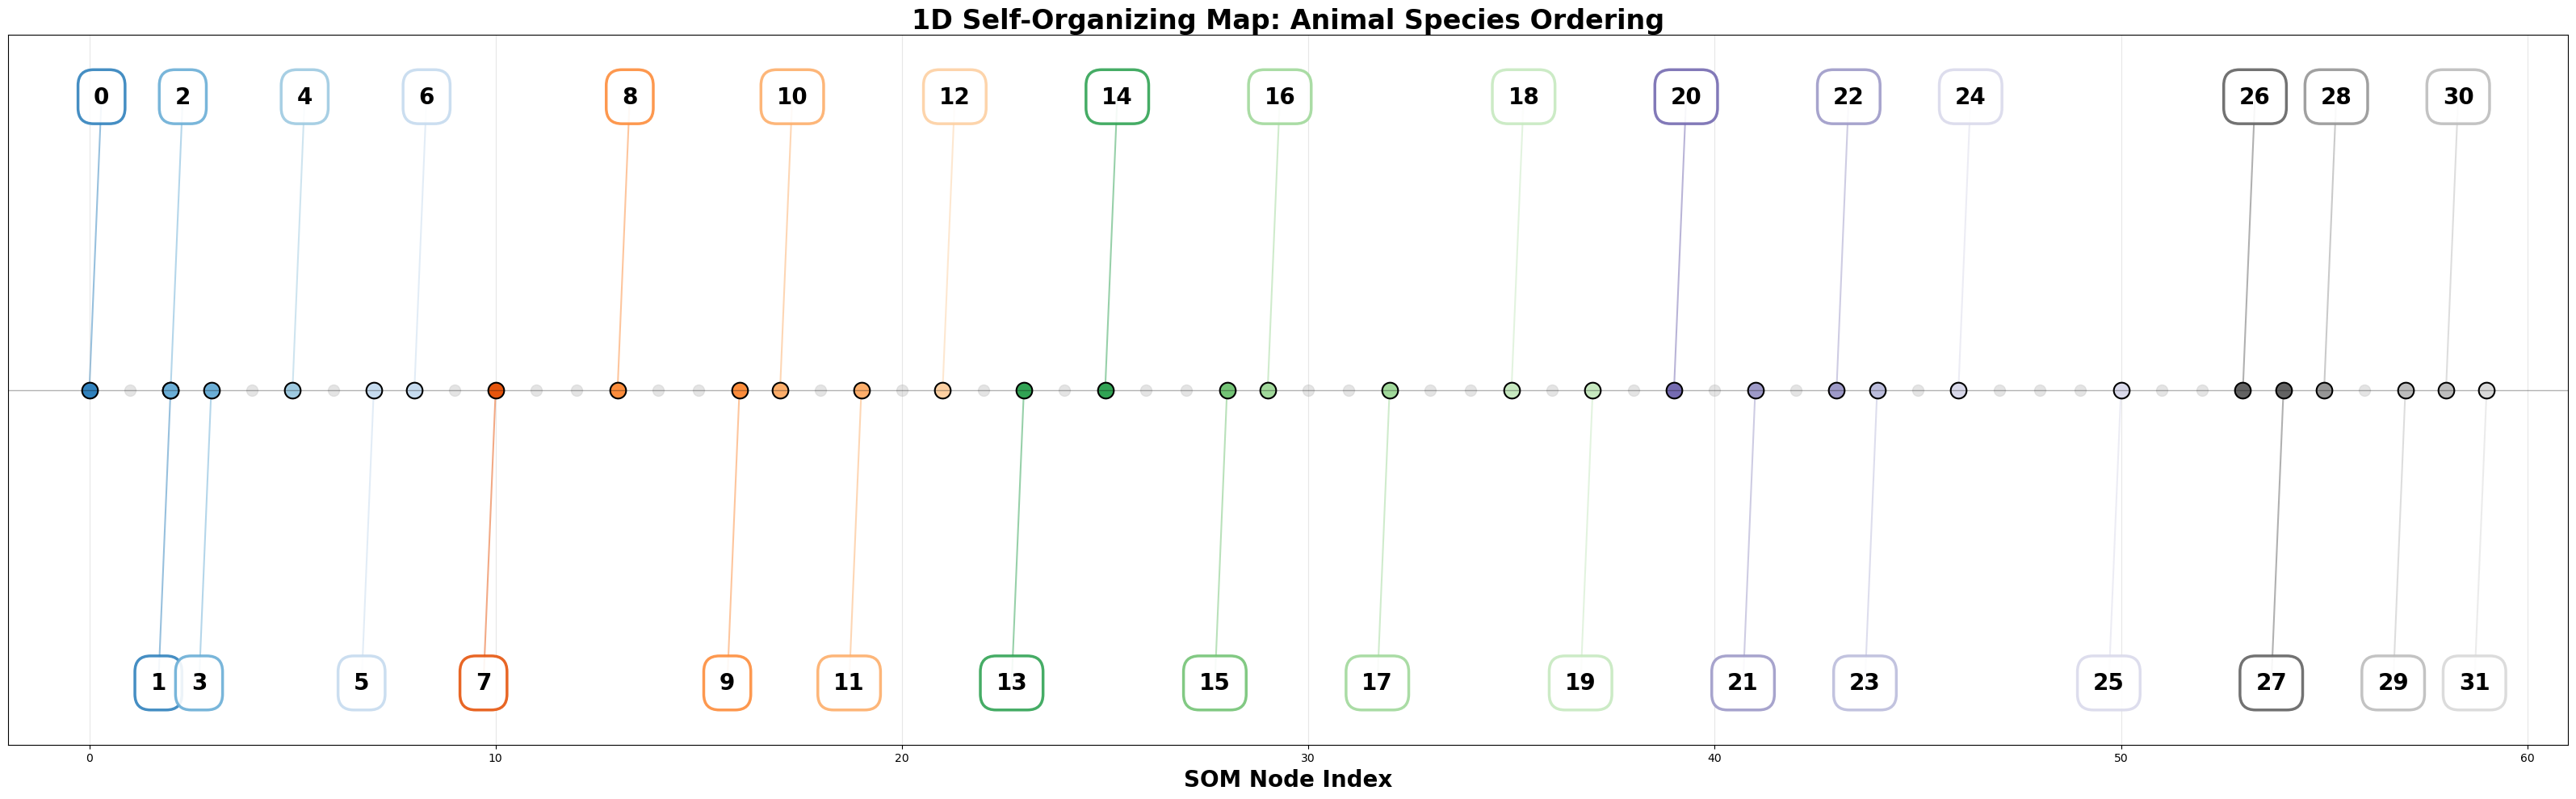

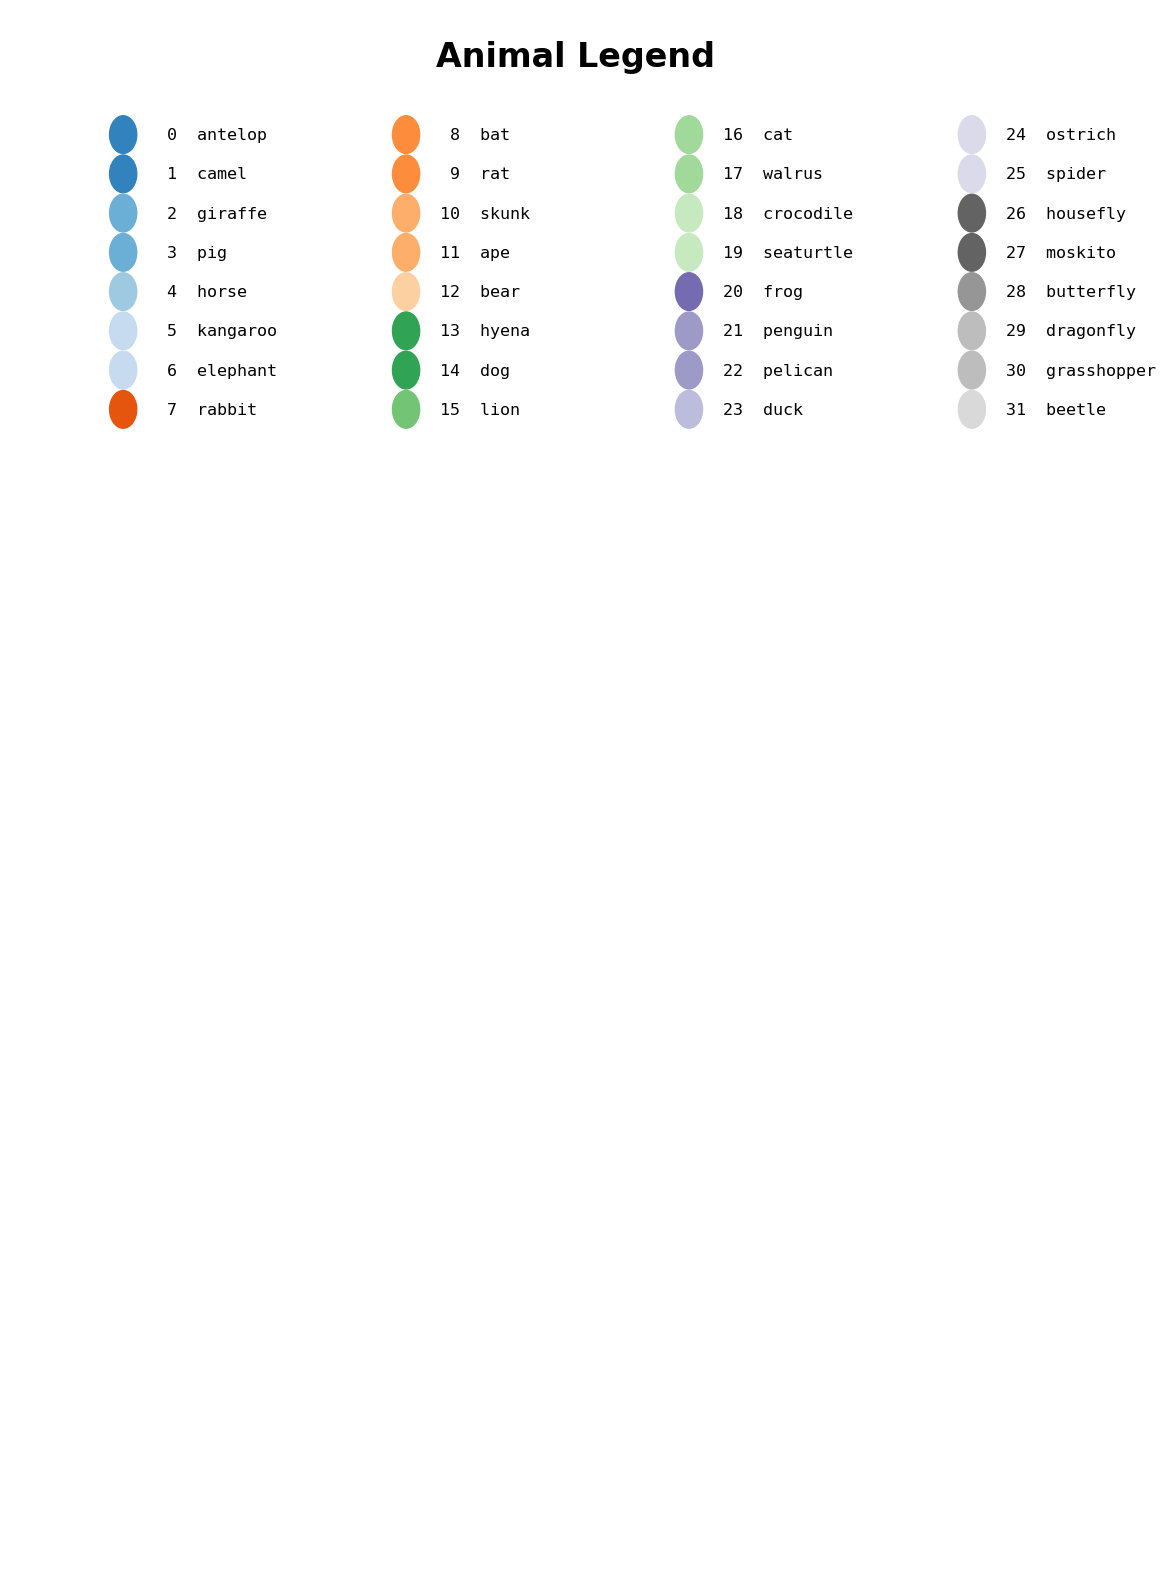


Animal Legend (number ↔ name):
--------------------------------------------------
  0  antelop
  1  camel
  2  giraffe
  3  pig
  4  horse
  5  kangaroo
  6  elephant
  7  rabbit
  8  bat
  9  rat
 10  skunk
 11  ape
 12  bear
 13  hyena
 14  dog
 15  lion
 16  cat
 17  walrus
 18  crocodile
 19  seaturtle
 20  frog
 21  penguin
 22  pelican
 23  duck
 24  ostrich
 25  spider
 26  housefly
 27  moskito
 28  butterfly
 29  dragonfly
 30  grasshopper
 31  beetle


In [141]:
# Cell 4 — Visualize 1D SOM with Animal Ordering (numbers + legend for names)

fig, ax = plt.subplots(figsize=(32, 10))

# Draw SOM nodes on the baseline
for i in range(n_nodes):
    ax.plot(i, 0, 'o', markersize=10, color='lightgray', zorder=1, alpha=0.6)

# Draw animals on their BMU positions with non-overlapping labels
colors = plt.cm.tab20c(np.arange(n_animals) / n_animals)
for idx, (i, name) in enumerate(zip(pos[order], ordered_names)):
    # Draw animal node using scatter for proper edge styling
    ax.scatter(i, 0, s=200, c=[colors[idx]], marker='o', zorder=2, 
              edgecolor='black', linewidth=1.5)
    
    # Alternate label positions above and below to avoid overlap
    # Even indices above, odd indices below
    label_y = 1.9 if idx % 2 == 0 else -1.9
    
    # Add horizontal staggering to prevent label box overlap
    # Stagger left/right based on whether label is above or below
    label_x_offset = 0.3 if idx % 2 == 0 else -0.3
    label_x = i + label_x_offset
    
    # Draw connector line from node to label
    ax.plot([i, label_x], [0, label_y], color=colors[idx], linewidth=1.5, 
            alpha=0.5, zorder=1)
    
    # Draw label with number instead of name - BIGGER FONT
    ax.text(label_x, label_y, str(idx), ha='center', va='center', fontsize=20, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.7', facecolor='white', 
                     edgecolor=colors[idx], alpha=0.9, linewidth=2.5))

# Set axis properties
ax.set_xlim(-2, n_nodes + 1)
ax.set_ylim(-2.3, 2.3)
ax.set_aspect('auto')
ax.axhline(y=0, color='black', linewidth=1, alpha=0.3, linestyle='-')

ax.set_xlabel('SOM Node Index', fontsize=20, fontweight='bold')
ax.set_title('1D Self-Organizing Map: Animal Species Ordering', fontsize=24, fontweight='bold')
ax.set_yticks([])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Create legend as a separate figure
fig_legend, ax_legend = plt.subplots(figsize=(12, 16))
ax_legend.axis('off')

# Title
ax_legend.text(0.5, 0.98, 'Animal Legend', fontsize=24, fontweight='bold', 
              ha='center', va='top', transform=ax_legend.transAxes)

# Display legend in four columns
n_cols = 4
n_per_col = (n_animals + n_cols - 1) // n_cols
y_start = 0.92
x_positions = [0.02 + 0.1, 0.27 + 0.1, 0.52 + 0.1, 0.77 + 0.1]

for idx, name in enumerate(ordered_names):
    col = idx // n_per_col
    row = idx % n_per_col
    
    x = x_positions[col]
    y = y_start - (row * 0.025)
    
    # Draw colored box with number
    circle = plt.Circle((x - 0.02, y), 0.012, color=colors[idx], transform=ax_legend.transAxes, zorder=2)
    ax_legend.add_patch(circle)
    
    # Draw number and name
    ax_legend.text(x + 0.01, y, f'{idx:2d}  {name}', fontsize=12, va='center',
                  transform=ax_legend.transAxes, fontfamily='monospace')

plt.tight_layout()
plt.show()

# Print legend showing number -> name mapping
print("\nAnimal Legend (number ↔ name):")
print("-" * 50)
for idx, name in enumerate(ordered_names):
    print(f"{idx:3d}  {name}")


/tmp/ipykernel_437977/3911037857.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_2d = plt.cm.get_cmap('tab20')


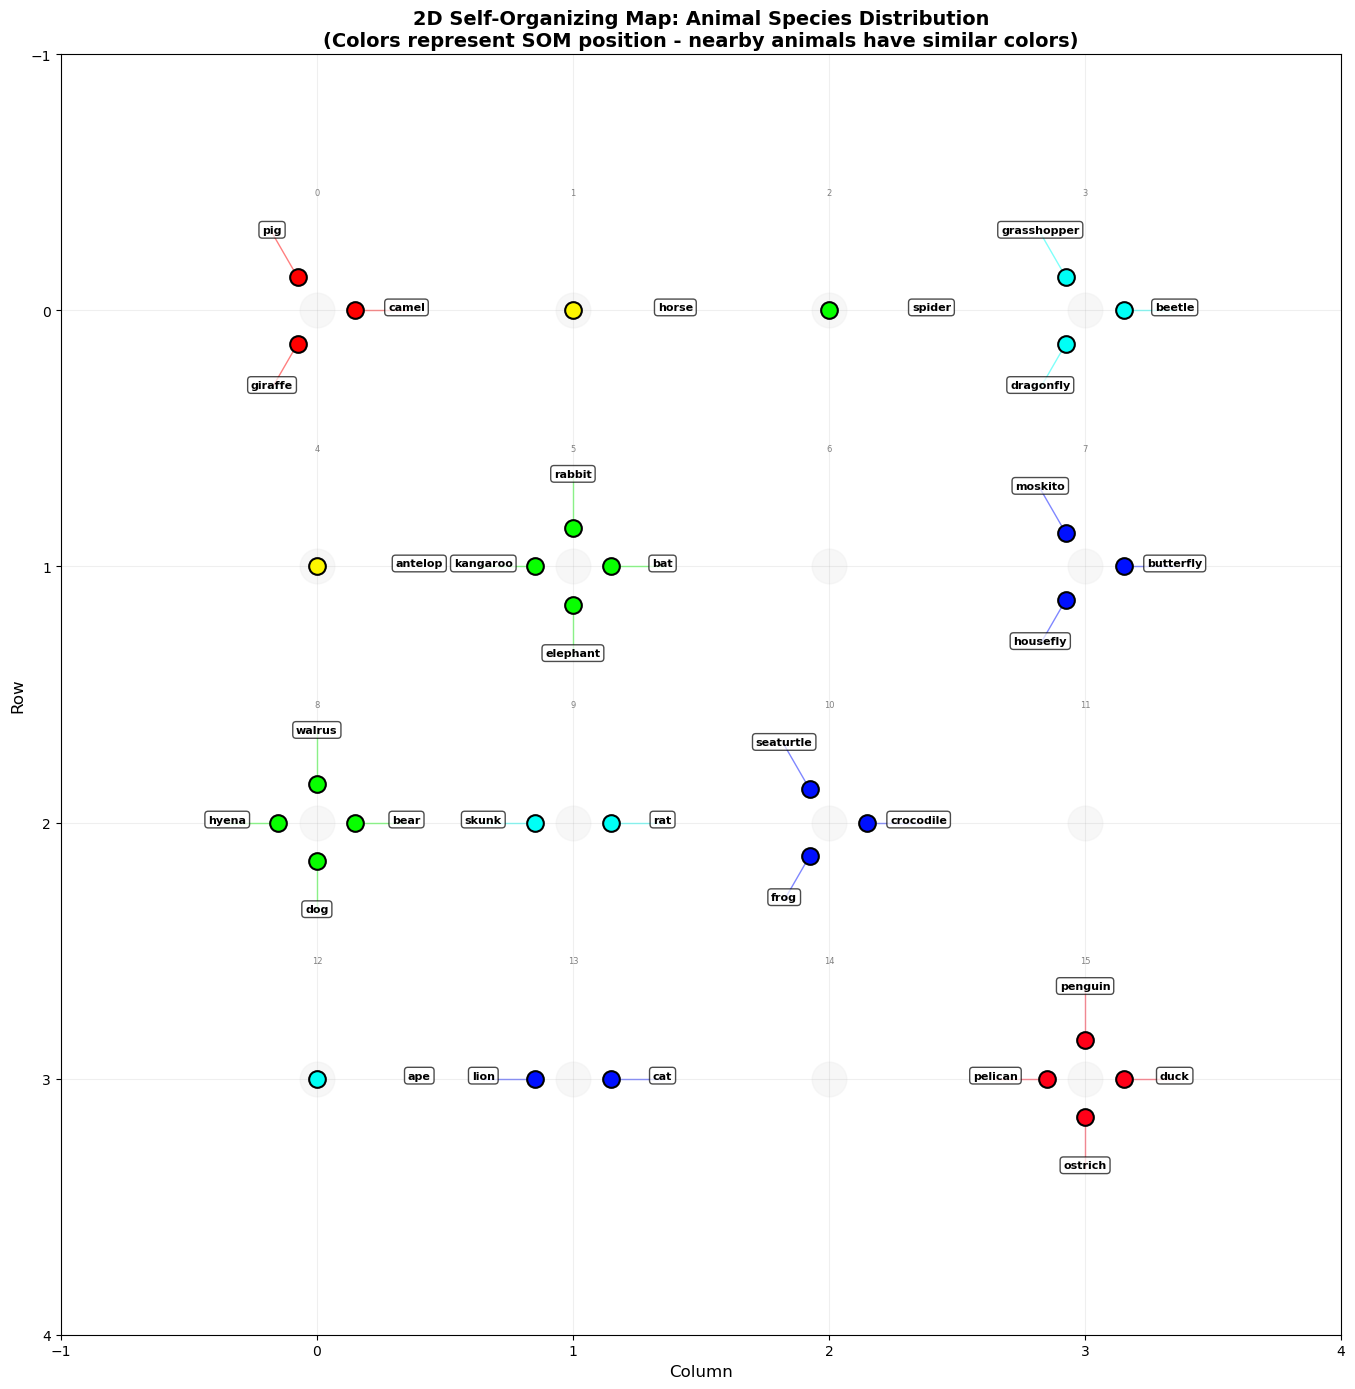


Node Occupancy:
--------------------------------------------------
Node 0 at (np.int64(0), np.int64(0)): 3 animals
  - camel
  - giraffe
  - pig
Node 3 at (np.int64(0), np.int64(3)): 3 animals
  - beetle
  - dragonfly
  - grasshopper
Node 5 at (np.int64(1), np.int64(1)): 4 animals
  - bat
  - elephant
  - kangaroo
  - rabbit
Node 7 at (np.int64(1), np.int64(3)): 3 animals
  - butterfly
  - housefly
  - moskito
Node 8 at (np.int64(2), np.int64(0)): 4 animals
  - bear
  - dog
  - hyena
  - walrus
Node 9 at (np.int64(2), np.int64(1)): 2 animals
  - rat
  - skunk
Node 10 at (np.int64(2), np.int64(2)): 3 animals
  - crocodile
  - frog
  - seaturtle
Node 13 at (np.int64(3), np.int64(1)): 2 animals
  - cat
  - lion
Node 15 at (np.int64(3), np.int64(3)): 4 animals
  - duck
  - ostrich
  - pelican
  - penguin


In [21]:
# Cell 5 — Train 2D SOM and Visualize

# Train a 2D SOM with a 6x6 grid (36 nodes)
grid_shape = (4, 4)
epochs_2d = 50
eta_2d = 0.2
r0_2d = 3  # start with neighborhood of ~3, decay to 0

W_2d = som_train_2d(props, grid_shape=grid_shape, epochs=epochs_2d, eta=eta_2d, r0=r0_2d, seed=0)

# Find 2D positions for each animal
pos_2d = []
for i in range(props.shape[0]):
    i_star = bmu_index(props[i], W_2d)
    r, c = divmod(i_star, grid_shape[1])
    pos_2d.append((r, c))
pos_2d = np.array(pos_2d)

# Group animals by their position
from collections import defaultdict
position_map = defaultdict(list)
for idx, pos in enumerate(pos_2d):
    position_map[tuple(pos)].append((idx, animal_names[idx]))

# Assign colors based on SOM position (so nearby animals get similar colors)
# Use 2D colormap to map (r, c) coordinates to colors
cmap_2d = plt.cm.get_cmap('tab20')
colors_2d = {}
for idx, (r, c) in enumerate(pos_2d):
    # Normalize position to [0, 1] for colormap
    norm_r = r / (grid_shape[0] - 1) if grid_shape[0] > 1 else 0.5
    norm_c = c / (grid_shape[1] - 1) if grid_shape[1] > 1 else 0.5
    # Use average of normalized coordinates to pick color
    color_idx = (norm_r + norm_c) / 2
    colors_2d[idx] = plt.cm.hsv(color_idx)  # HSV colormap varies smoothly with position

# Create 2D visualization with better label handling
fig, ax = plt.subplots(figsize=(14, 14))

# Draw grid background
for r in range(grid_shape[0]):
    for c in range(grid_shape[1]):
        ax.plot(c, r, 'o', markersize=25, color='#f0f0f0', zorder=1, alpha=0.5)
        ax.text(c, r - 0.45, f'{r*grid_shape[1]+c}', ha='center', fontsize=6, color='gray')

# Plot animals at their 2D positions with arranged labels
for (r, c), animals_at_pos in position_map.items():
    n_at_pos = len(animals_at_pos)
    
    # Arrange labels in a circle or line around the node
    for i, (idx, name) in enumerate(animals_at_pos):
        if n_at_pos == 1:
            # Single animal: place at center
            offset_r, offset_c = 0, 0
            label_offset_r, label_offset_c = 0, 0.4
        else:
            # Multiple animals: arrange in circle
            angle = 2 * np.pi * i / n_at_pos
            offset_r = 0.15 * np.sin(angle)
            offset_c = 0.15 * np.cos(angle)
            label_offset_r = 0.35 * np.sin(angle)
            label_offset_c = 0.35 * np.cos(angle)
        
        # Draw animal node
        ax.plot(c + offset_c, r + offset_r, 'o', markersize=12, color=colors_2d[idx], 
                zorder=2, markeredgecolor='black', markeredgewidth=1.5)
        
        # Draw label with line connection if multiple at same position
        if n_at_pos > 1:
            ax.plot([c + offset_c, c + label_offset_c], [r + offset_r, r + label_offset_r], 
                   color=colors_2d[idx], linewidth=1, alpha=0.5, zorder=1)
        
        ax.text(c + label_offset_c, r + label_offset_r, name, ha='center', fontsize=8, 
               fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlim(-1, grid_shape[1])
ax.set_ylim(-1, grid_shape[0])
ax.invert_yaxis()  # invert y-axis so (0,0) is at top-left
ax.set_aspect('equal')
ax.set_xlabel('Column', fontsize=12)
ax.set_ylabel('Row', fontsize=12)
ax.set_title('2D Self-Organizing Map: Animal Species Distribution\n(Colors represent SOM position - nearby animals have similar colors)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Print node occupancy statistics
print("\nNode Occupancy:")
print("-" * 50)
for pos in sorted(position_map.keys()):
    animals = position_map[pos]
    if len(animals) > 1:
        node_idx = pos[0] * grid_shape[1] + pos[1]
        print(f"Node {node_idx} at {pos}: {len(animals)} animals")
        for idx, name in animals:
            print(f"  - {name}")

### Part 2: Travelling Salesman Problem with Circular SOM

The SOM algorithm can also be used to find an approximate solution to the Travelling Salesman Problem. 
A 1D circular SOM is trained on city coordinates (2D input space), positioning its 10 nodes as a tour through the cities.

In [105]:
# Cell 6 — Load city data

cities_path = DATA_DIR / "cities.dat"

# Load cities with custom parsing (skip comments, handle semicolons)
with open(cities_path, 'r') as f:
    lines = f.readlines()

# Filter out comments and empty lines, remove semicolons
data_lines = []
for line in lines:
    line = line.strip()
    if line and not line.startswith('%'):  # skip comments and empty lines
        # Remove semicolon at end if present
        line = line.rstrip(';')
        data_lines.append(line)

# Parse the data
cities = np.array([list(map(float, line.split(','))) for line in data_lines])

print("cities shape:", cities.shape)
print("First 3 cities:")
print(cities[:3])
print("\nAll cities:")
for i, city in enumerate(cities):
    print(f"City {i}: {city}")

cities shape: (10, 2)
First 3 cities:
[[0.4    0.4439]
 [0.2439 0.1463]
 [0.1707 0.2293]]

All cities:
City 0: [0.4    0.4439]
City 1: [0.2439 0.1463]
City 2: [0.1707 0.2293]
City 3: [0.2293 0.761 ]
City 4: [0.5171 0.9414]
City 5: [0.8732 0.6536]
City 6: [0.6878 0.5219]
City 7: [0.8488 0.3609]
City 8: [0.6683 0.2536]
City 9: [0.6195 0.2634]


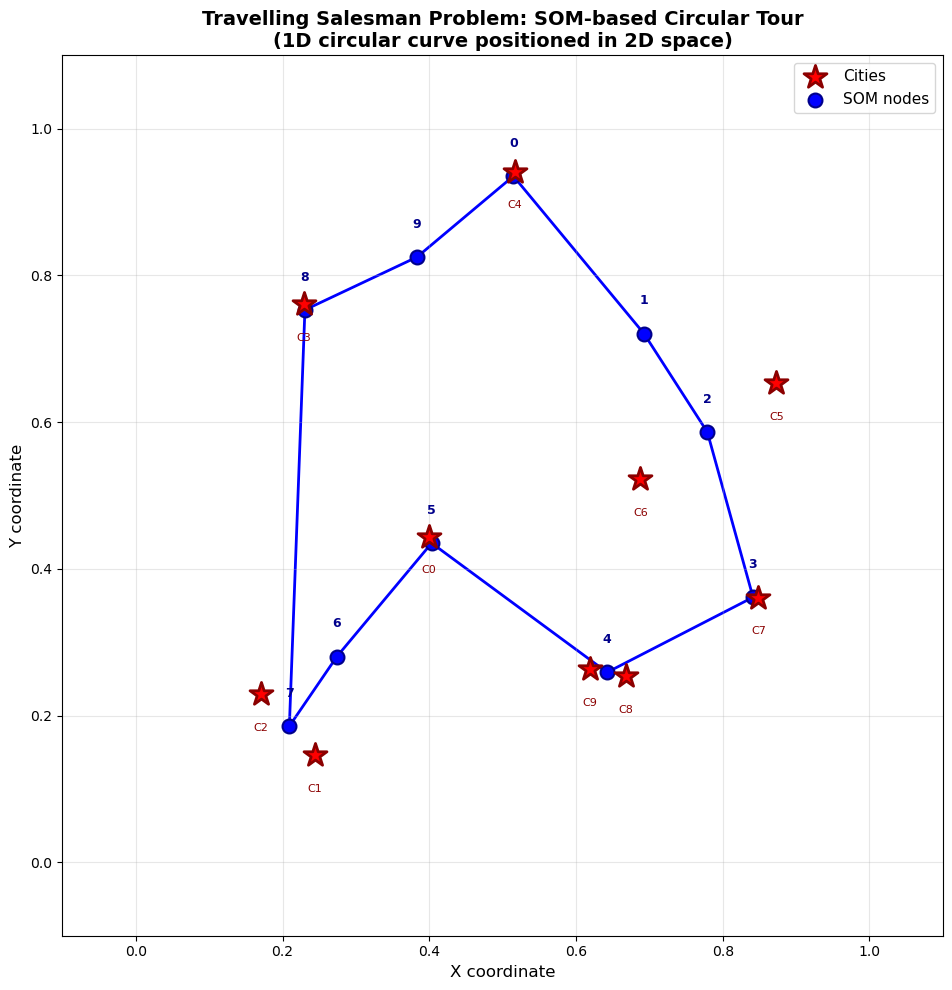


Tour Analysis:
--------------------------------------------------
SOM nodes (circular tour order): 10

Tour node positions (in order):
  Node 0: (0.5147, 0.9354)
  Node 1: (0.6928, 0.7205)
  Node 2: (0.7791, 0.5865)
  Node 3: (0.8414, 0.3613)
  Node 4: (0.6425, 0.2590)
  Node 5: (0.4033, 0.4352)
  Node 6: (0.2741, 0.2805)
  Node 7: (0.2094, 0.1857)
  Node 8: (0.2306, 0.7530)
  Node 9: (0.3833, 0.8250)

Distance from node 0 to node 1: 0.2791

Distance from node 1 to node 2: 0.1593

Distance from node 2 to node 3: 0.2336

Total tour length: 2.4173


In [137]:
# Cell 7 — Train circular 1D SOM for TSP + visualize tour
# The SOM positions a 1D circular curve (tour) in 2D space through the cities

epochs_tsp = 50
eta_tsp = 0.2
n_nodes_tsp = 10  # 10 nodes for the 10 cities
r0_tsp = 2  # start with neighborhood size 2, decay to 1, then 0

W_cities = som_train_1d(cities, n_nodes=n_nodes_tsp, epochs=epochs_tsp, eta=eta_tsp, r0=r0_tsp,
                        circular=True, shuffle_each_epoch=True, seed=1)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Plot cities
ax.scatter(cities[:, 0], cities[:, 1], s=300, c='red', marker='*', zorder=3, edgecolor='darkred', linewidth=2, label='Cities')

# Plot SOM nodes
ax.scatter(W_cities[:, 0], W_cities[:, 1], s=100, c='blue', marker='o', zorder=2, edgecolor='darkblue', linewidth=1.5, label='SOM nodes')

# Connect SOM nodes in circular order to show the tour
for i in range(n_nodes_tsp):
    next_i = (i + 1) % n_nodes_tsp
    ax.plot([W_cities[i, 0], W_cities[next_i, 0]], [W_cities[i, 1], W_cities[next_i, 1]], 'b-', linewidth=2, zorder=1)

# Add node indices
for i in range(n_nodes_tsp):
    ax.text(W_cities[i, 0], W_cities[i, 1] + 0.04, f'{i}', ha='center', fontsize=9, fontweight='bold', color='darkblue')

# Add city indices
for i in range(len(cities)):
    ax.text(cities[i, 0], cities[i, 1] - 0.05, f'C{i}', ha='center', fontsize=8, color='darkred')

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('X coordinate', fontsize=12)
ax.set_ylabel('Y coordinate', fontsize=12)
ax.set_title('Travelling Salesman Problem: SOM-based Circular Tour\n(1D circular curve positioned in 2D space)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# Print tour statistics
print("\nTour Analysis:")
print("-" * 50)
print(f"SOM nodes (circular tour order): {n_nodes_tsp}")
print(f"\nTour node positions (in order):")
for i in range(n_nodes_tsp):
    print(f"  Node {i}: ({W_cities[i, 0]:.4f}, {W_cities[i, 1]:.4f})")

# Calculate tour length
tour_length = 0
for i in range(n_nodes_tsp):
    curr = W_cities[i]
    next_node = W_cities[(i + 1) % n_nodes_tsp]
    dist = np.linalg.norm(next_node - curr)
    tour_length += dist
    if i < 3:
        print(f"\nDistance from node {i} to node {(i+1)%n_nodes_tsp}: {dist:.4f}")

print(f"\nTotal tour length: {tour_length:.4f}")

### Part 3: Data Clustering - Votes of Swedish MPs

Use SOM to position 349 members of Swedish parliament on a 10×10 grid based on their voting patterns (31 votes).
Then analyze the clustering by party affiliation, gender, and district to understand voting behavior patterns.

In [32]:
# Cell 9 — Load voting data + MP labels (robust parsing)

votes_path = DATA_DIR / "votes.dat"
votes = np.loadtxt(votes_path, delimiter=",")  # expected shape (349,31)
# Ensure votes is 2D: if it loaded as 1D, reshape it
if votes.ndim == 1:
    votes = votes.reshape(349, -1)

party_path = DATA_DIR / "mpparty.dat"
sex_path = DATA_DIR / "mpsex.dat"
district_path = DATA_DIR / "mpdistrict.dat"
mpnames_path = DATA_DIR / "mpnames.txt"

# Helper function to load data files with comments
def load_data_with_comments(path):
    """Load numeric data from file, skipping comments and empty lines."""
    with open(path, 'r') as f:
        lines = f.readlines()

    data = []
    for line in lines:
        line = line.strip()
        if line and not line.startswith('%'):  # skip comments and empty lines
            # Handle both single values and comma-separated
            values = line.replace(',', ' ').split()
            for val in values:
                if val:  # skip empty strings
                    data.append(float(val))
    return np.array(data, dtype=int)

mpparty = load_data_with_comments(party_path)
mpsex = load_data_with_comments(sex_path)
mpdistrict = load_data_with_comments(district_path)

# Load MP names
if mpnames_path.exists():
    mpnames = [line.strip().strip("'") for line in mpnames_path.read_text(encoding="latin-1").splitlines() if line.strip()]
else:
    mpnames = [f"MP_{i}" for i in range(len(mpparty))]

print("votes shape:", votes.shape)
print("party shape:", mpparty.shape, "unique parties:", np.unique(mpparty))
print("sex shape:", mpsex.shape, "unique values:", np.unique(mpsex), "(0=Male, 1=Female)")
print("district shape:", mpdistrict.shape, "unique districts:", sorted(np.unique(mpdistrict)))
print(f"\nTotal MPs: {len(mpparty)}")

votes shape: (349, 31)
party shape: (349,) unique parties: [0 1 2 3 4 5 6 7]
sex shape: (349,) unique values: [0 1] (0=Male, 1=Female)
district shape: (349,) unique districts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]

Total MPs: 349


In [33]:
# Cell 10 — Train 10x10 SOM on voting patterns

epochs_mp = 30
eta_mp = 0.2
grid_shape_mp = (10, 10)
r0_mp = 5  # start with broad neighborhood, shrink to 0

print("Training 10x10 SOM on 349 MPs with 31-dimensional voting patterns...")
W_votes = som_train_2d(votes, grid_shape=grid_shape_mp, epochs=epochs_mp, eta=eta_mp, r0=r0_mp,
                       shuffle_each_epoch=True, seed=2)

# Map each MP to their Best Matching Unit (BMU) on the grid
bmus = np.array([bmu_index(votes[i], W_votes) for i in range(votes.shape[0])], dtype=int)
rows = bmus // grid_shape_mp[1]  # row index in grid
cols = bmus % grid_shape_mp[1]   # column index in grid

print(f"SOM training complete. MPs distributed across {grid_shape_mp[0]}x{grid_shape_mp[1]} grid.")
print(f"Occupied cells: {len(np.unique(bmus))} / {grid_shape_mp[0] * grid_shape_mp[1]}")

Training 10x10 SOM on 349 MPs with 31-dimensional voting patterns...
SOM training complete. MPs distributed across 10x10 grid.
Occupied cells: 59 / 100


In [120]:
# Cell 11 — Visualization helper function

# Pre-compute jitter for consistent positioning across all plots
jitter_amount = 0.15
jitter_seed = 42
rng_jitter = np.random.default_rng(jitter_seed)
jitter_x = rng_jitter.uniform(-jitter_amount, jitter_amount, size=len(rows))
jitter_y = rng_jitter.uniform(-jitter_amount, jitter_amount, size=len(rows))

def plot_som_map(rows, cols, labels, title, label_names=None, cmap='tab20', jitter_x=None, jitter_y=None):
    """Plot MPs on SOM grid colored by attribute."""
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use provided jitter or create new ones
    if jitter_x is None or jitter_y is None:
        j = 0.15
        x_jittered = cols + np.random.uniform(-j, j, size=len(cols))
        y_jittered = rows + np.random.uniform(-j, j, size=len(rows))
    else:
        x_jittered = cols + jitter_x
        y_jittered = rows + jitter_y
    
    # Create scatter plot
    scatter = ax.scatter(x_jittered, y_jittered, c=labels, s=80, marker='o', cmap=cmap, 
                       edgecolor='black', linewidth=0.5, alpha=0.7)
    
    # Set up grid
    ax.invert_yaxis()
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.grid(True, linewidth=0.5, alpha=0.5)
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)
    
    ax.set_xlabel('Column', fontsize=20)
    ax.set_ylabel('Row', fontsize=20)
    ax.set_title(title, fontsize=24, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    if label_names is not None:
        cbar.set_label('Category', fontsize=22)
    else:
        cbar.set_label('Value', fontsize=18)
    
    plt.tight_layout()
    plt.show()

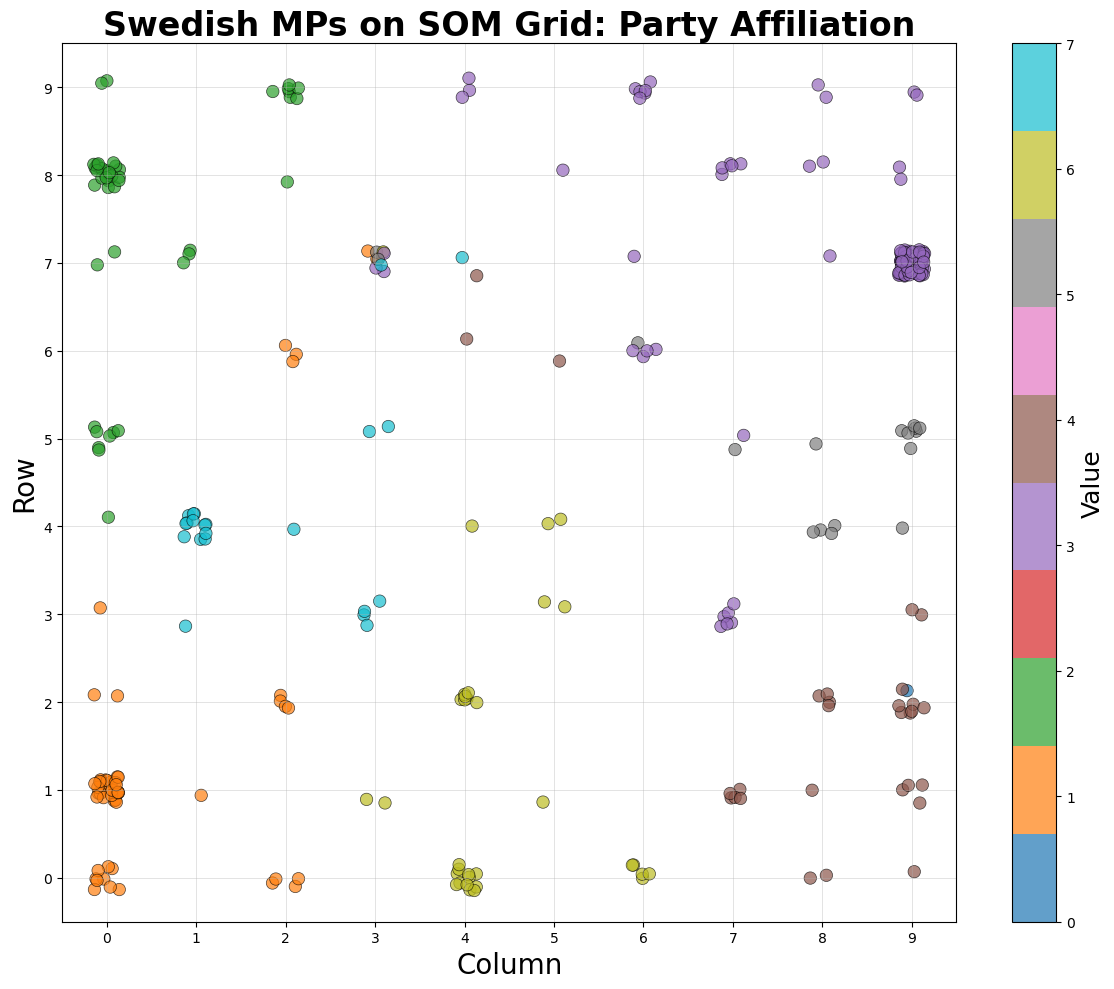


Party Distribution on SOM:
--------------------------------------------------
No Party    :   1 MPs
M           :  55 MPs
FP          :  48 MPs
S           : 144 MPs
V           :  29 MPs
MP          :  17 MPs
KD          :  33 MPs
C           :  22 MPs


In [123]:
# Cell 12 — Visualize SOM by Party Affiliation

# Party coding: 0=no party, 1='m', 2='fp', 3='s', 4='v', 5='mp', 6='kd', 7='c'
party_names = {0: 'No Party', 1: 'M', 2: 'FP', 3: 'S', 4: 'V', 5: 'MP', 6: 'KD', 7: 'C'}


plot_som_map(rows, cols, mpparty, 'Swedish MPs on SOM Grid: Party Affiliation', cmap='tab10', jitter_x=jitter_x, jitter_y=jitter_y)


# Print party distribution
print("\nParty Distribution on SOM:")
print("-" * 50)
for party_id in sorted(np.unique(mpparty)):
    count = np.sum(mpparty == party_id)
    party_name = party_names.get(party_id, f'Party {party_id}')
    print(f"{party_name:12s}: {count:3d} MPs")

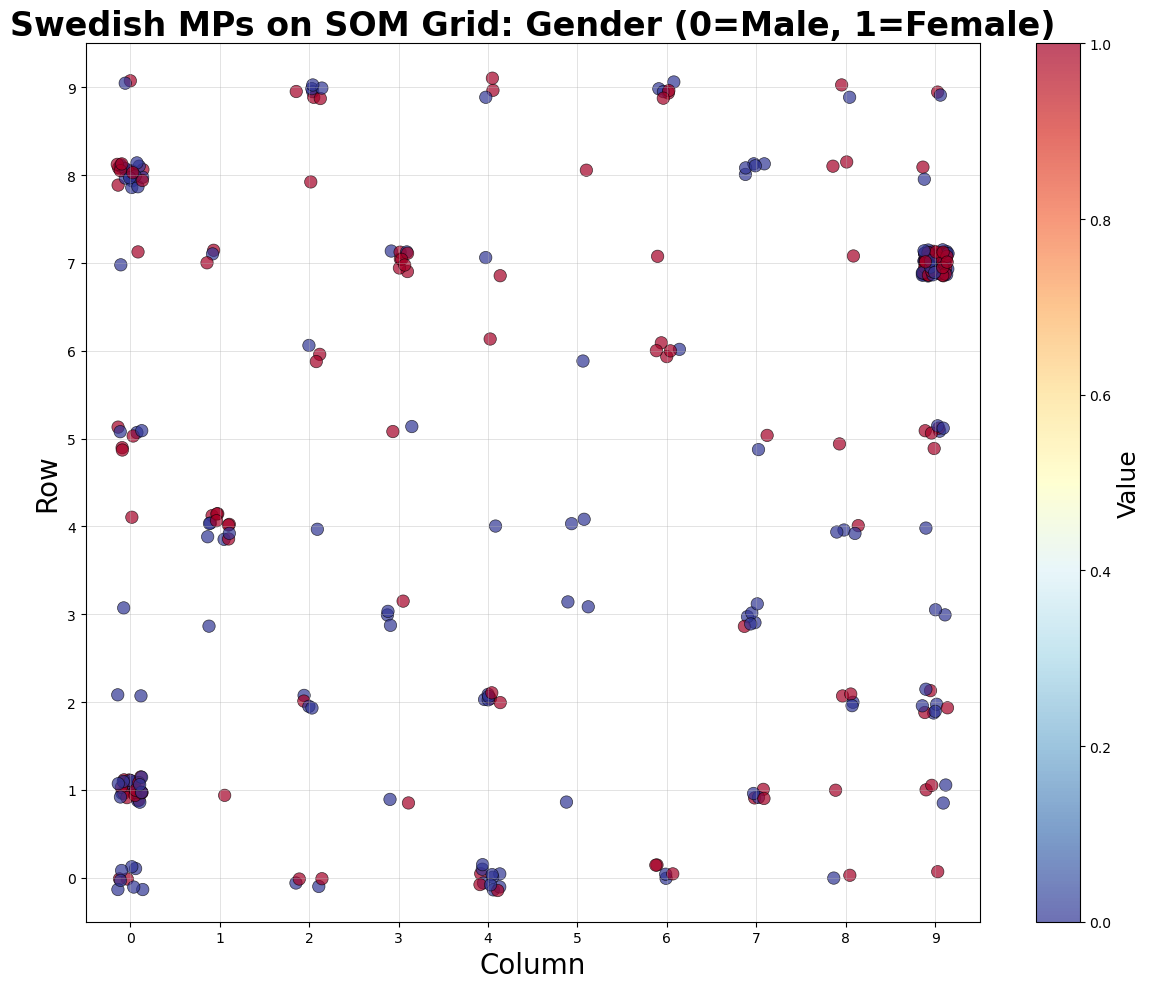


Gender Distribution on SOM:
--------------------------------------------------
Male:   186 MPs (53.3%)
Female: 163 MPs (46.7%)


In [124]:
# Cell 13 — Visualize SOM by Gender

plot_som_map(rows, cols, mpsex, 'Swedish MPs on SOM Grid: Gender (0=Male, 1=Female)', cmap='RdYlBu_r', jitter_x=jitter_x, jitter_y=jitter_y)


# Print gender distribution
print("\nGender Distribution on SOM:")
print("-" * 50)
male_count = np.sum(mpsex == 0)
female_count = np.sum(mpsex == 1)
print(f"Male:   {male_count:3d} MPs ({100*male_count/len(mpsex):.1f}%)")
print(f"Female: {female_count:3d} MPs ({100*female_count/len(mpsex):.1f}%)")

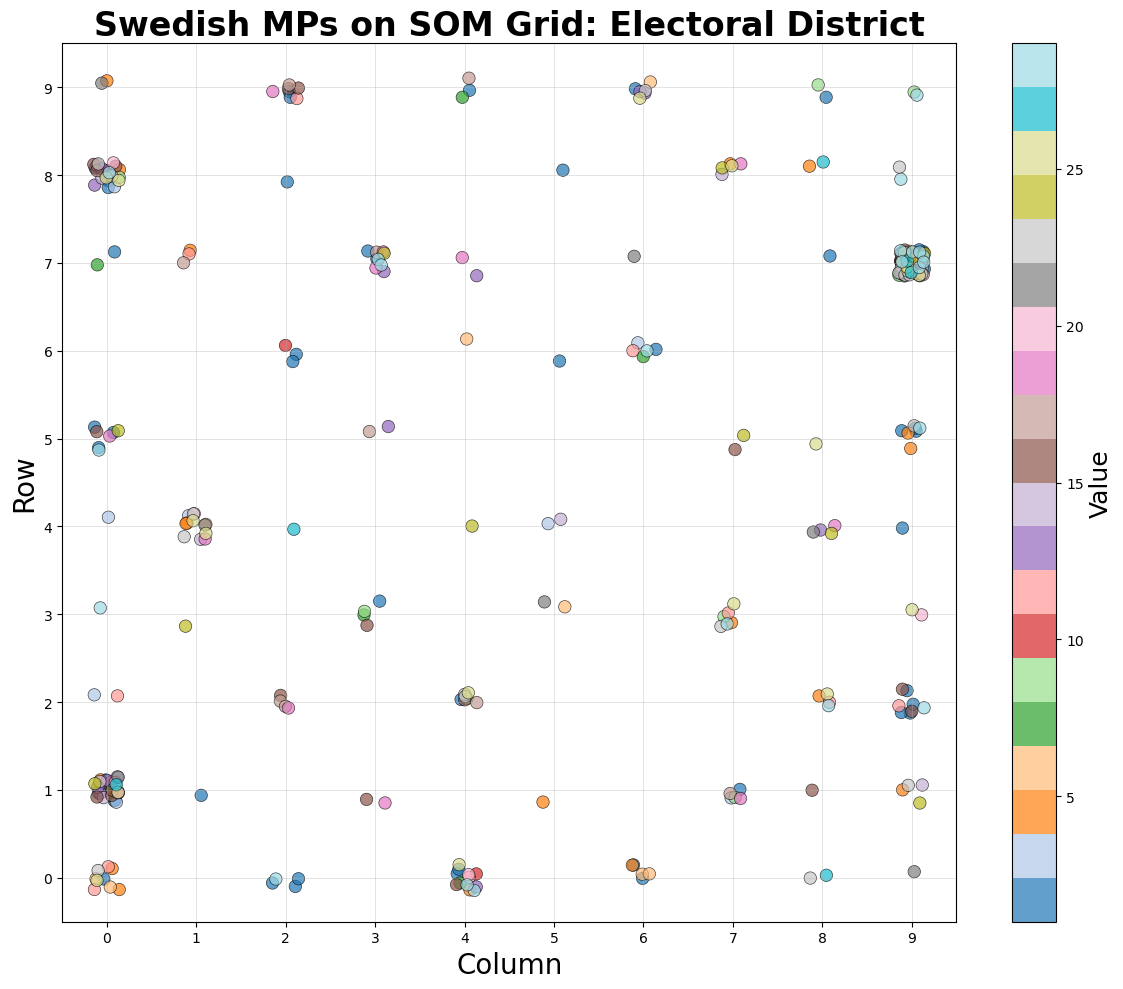


District Distribution on SOM:
--------------------------------------------------
District  1:  29 MPs
District  2:  39 MPs
District  3:  12 MPs
District  4:  11 MPs
District  5:  17 MPs
District  6:  13 MPs
District  7:   7 MPs
District  8:   9 MPs
District  9:   2 MPs
District 10:   6 MPs
District 11:   9 MPs
District 12:  10 MPs
District 13:  14 MPs
District 14:  11 MPs
District 15:  11 MPs
District 16:  18 MPs
District 17:  13 MPs
District 18:  10 MPs
District 19:   7 MPs
District 20:   9 MPs
District 21:  11 MPs
District 22:  11 MPs
District 23:  10 MPs
District 24:  11 MPs
District 25:  11 MPs
District 26:  10 MPs
District 27:   6 MPs
District 28:  11 MPs
District 29:  11 MPs


In [125]:
# Cell 14 — Visualize SOM by District

plot_som_map(rows, cols, mpdistrict, 'Swedish MPs on SOM Grid: Electoral District', cmap='tab20', jitter_x=jitter_x, jitter_y=jitter_y)


# Print district distribution
print("\nDistrict Distribution on SOM:")
print("-" * 50)
for district_id in sorted(np.unique(mpdistrict)):
    count = np.sum(mpdistrict == district_id)
    print(f"District {district_id:2d}: {count:3d} MPs")

## Analysis and Interpretation

### Key Findings:

**Party Distribution:**
- The SOM reveals how Swedish political parties cluster based on voting patterns
- Left-wing parties (V, S) and right-wing parties (M, C, FP, KD) should show spatial separation if voting reflects the traditional left-right political spectrum
- The layout should reveal natural political groupings

**Gender Distribution:**
- Comparison of male and female MP positions shows whether gender influences voting behavior
- If males and females are randomly distributed, gender has minimal voting impact
- Clustering by gender would suggest gender-based voting differences

**District Distribution:**
- Electoral districts may show spatial patterns if regional interests affect voting
- Geographic districts that vote similarly should cluster together on the map
- Strong district clustering would indicate regional voting patterns

In [4]:
# Cell 6 — Load voting + labels (robust to whitespace)

votes_path = DATA_DIR / "votes.dat"
votes = np.loadtxt(votes_path, delimiter=",")  # expected shape (349,31)
# Ensure votes is 2D: if it loaded as 1D, reshape it
if votes.ndim == 1:
    votes = votes.reshape(349, -1)

party_path = DATA_DIR / "mpparty.dat"
sex_path = DATA_DIR / "mpsex.dat"
district_path = DATA_DIR / "mpdistrict.dat"

mpparty = np.loadtxt(party_path, dtype=int)
mpsex = np.loadtxt(sex_path, dtype=int)
mpdistrict = np.loadtxt(district_path, dtype=int)

print("votes:", votes.shape, "party:", mpparty.shape, "sex:", mpsex.shape, "district:", mpdistrict.shape)
print("party unique:", np.unique(mpparty))
print("sex unique:", np.unique(mpsex))
print("district unique:", np.unique(mpdistrict))

ValueError: could not convert string '0,1,0,0.5,0,0,1,0.5,0,0,1,0,0,1,1,1,1,0,1,1,0,1,0,1,0.5,0.5,1,0,0.5,0,1,0,1,1,0.5,0,0,1,0.5,0,0,0.5 to float64 at row 0, column 1.